# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [5]:
import sklearn
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.svm import SVC

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [2]:
from scipy.io import loadmat

data = loadmat('data/ejer_1_data1.mat')
print(data.keys())   # variables dentro del .mat

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


In [3]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

#### 3. Create a DataFrame with the features and target

In [4]:
df = pd.DataFrame({
    'X1': [fila[0] for fila in data['X']],
    'X2': [fila[1] for fila in data['X']],
    'y':  [fila[0] for fila in data['y']]})
df.head()

,X1,X2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      51 non-null     float64
 1   X2      51 non-null     float64
 2   y       51 non-null     uint8  
dtypes: float64(2), uint8(1)
memory usage: 999.0 bytes


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
X1,51.0,2.268780,0.928531,0.086405,1.57255,2.2753,2.95505,4.0150
X2,51.0,3.132512,0.753256,1.617700,2.63600,3.0709,3.53140,4.6162
y,51.0,0.411765,0.497050,0.000000,0.00000,0.0000,1.00000,1.0000


#### 4. Plot a scatterplot with the data

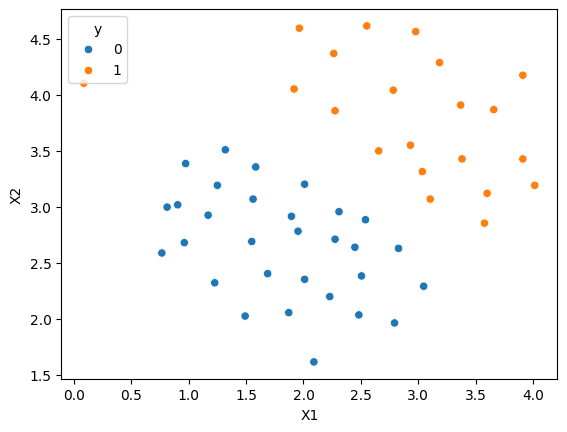

In [6]:
sns.scatterplot(data=df,x='X1',y='X2',hue='y');

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['X1','X2']]
y = df['y']

# Separamos train/test, aunque no lo uso. Uso todos los datos porque hay un outlier que no siempre se mete en el grupo de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# SVM Classifier model
svm_clf = LinearSVC(C=1, loss="hinge", max_iter = 10000, random_state=42)

scaler = StandardScaler()

scaled_svm_clf1 = Pipeline([
        ('scaler', scaler),
        ('linear_svc', svm_clf),
    ])

# Lo entrenamos con todos los datos para asegurarnos que el outlier queda dentro
# scaled_svm_clf1.fit(X_train,y_train)
scaled_svm_clf1.fit(X,y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linear_svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = scaled_svm_clf1.predict(X)

print('Accuracy:', accuracy_score(y, y_pred))
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

Accuracy: 0.9803921568627451
[[30  0]
 [ 1 20]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.95      0.98        21

    accuracy                           0.98        51
   macro avg       0.98      0.98      0.98        51
weighted avg       0.98      0.98      0.98        51



It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

Probamos diferentes valores, a partir de C=15 tenemos una clasificación perfecta.

In [30]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# SVM Classifier model
svm_clf = LinearSVC(C=15, loss="hinge", max_iter = 10000, random_state=42)

scaler = StandardScaler()

scaled_svm_clf1 = Pipeline([
        ('scaler', scaler),
        ('linear_svc', svm_clf),
    ])

# scaled_svm_clf1.fit(X_train,y_train)
scaled_svm_clf1.fit(X,y)


y_pred = scaled_svm_clf1.predict(X)

print('Accuracy:', accuracy_score(y, y_pred))
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

Accuracy: 1.0
[[30  0]
 [ 0 21]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        21

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51



This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

c:\Users\urkow\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


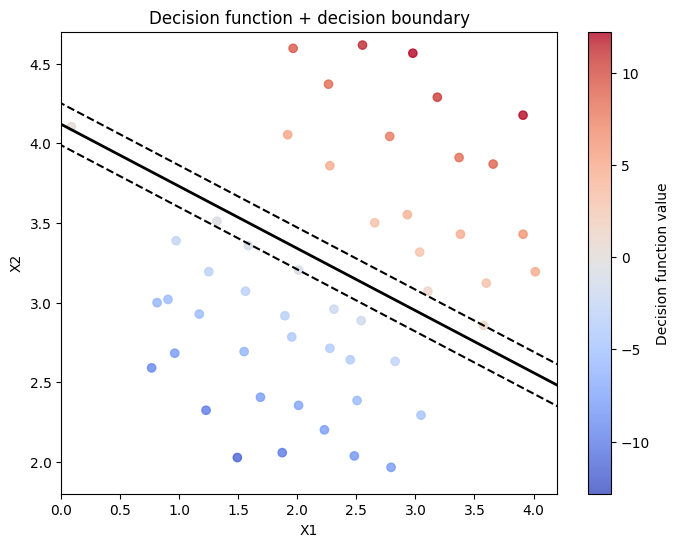

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Obtener decision_function
decision_values = scaled_svm_clf1.decision_function(X)

# Crear una malla de puntos (grid)
x_min, x_max = X['X1'].min() - 1, X['X1'].max() + 1
y_min, y_max = X['X2'].min() - 1, X['X2'].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Evaluar el decision_function en toda la malla
Z = scaled_svm_clf1.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Scatter original
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X['X1'],
    X['X2'],
    c=decision_values,
    cmap='coolwarm',
    alpha=0.8
)

plt.colorbar(scatter, label='Decision function value')

# Dibujar la frontera y los márgenes
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)      # frontera
plt.contour(xx, yy, Z, levels=[-1, 1], colors='black', linestyles='--')

plt.xlim(0, 4.2)
plt.ylim(1.8, 4.7)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Decision function + decision boundary')
plt.show();


#### 9. Do the same with the second model

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

#### 1. Load the data `ejer_1_data2.mat`

In [ ]:
from scipy.io import loadmat

data2 = loadmat('data/ejer_1_data2.mat')
print(data.keys())   # variables dentro del .mat
data2

#### 2. Create a DataFrame with the features and target

In [35]:
df2 = pd.DataFrame({
    'X1': [fila[0] for fila in data2['X']],
    'X2': [fila[1] for fila in data2['X']],
    'y':  [fila[0] for fila in data2['y']]})
df2.head()

,X1,X2,y
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1


#### 3. Plot a scatterplot with the data

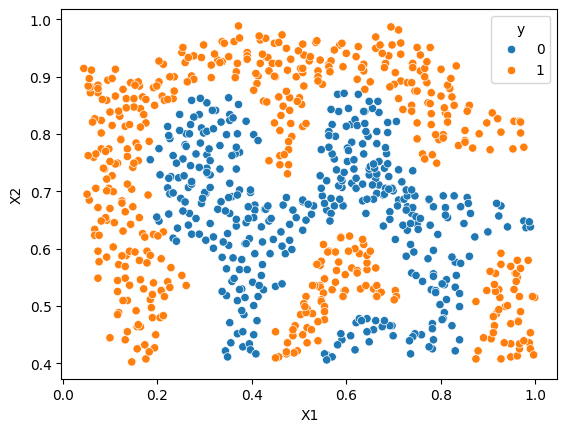

In [36]:
sns.scatterplot(data=df2,x='X1',y='X2',hue='y');


For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [ ]:
from sklearn.model_selection import train_test_split

X2 = df2[['X1','X2']]
y2 = df2['y']

# Separamos train/test, aunque no lo uso. Uso todos los datos para que se represente el conjunto entero en la gráfica
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.pipeline import Pipeline

svc = SVC(C=100, gamma=10, probability=True, random_state=42)

svc.fit(X2, y2)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",10
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### 5. Fit the classifier and get the score

In [60]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred2 = svc.predict(X2)

print('Accuracy:', accuracy_score(y2, y_pred2))
print(confusion_matrix(y2, y_pred2))
print(classification_report(y2, y_pred2))

Accuracy: 0.9698725376593279
[[375   8]
 [ 18 462]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       383
           1       0.98      0.96      0.97       480

    accuracy                           0.97       863
   macro avg       0.97      0.97      0.97       863
weighted avg       0.97      0.97      0.97       863



#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

c:\Users\urkow\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


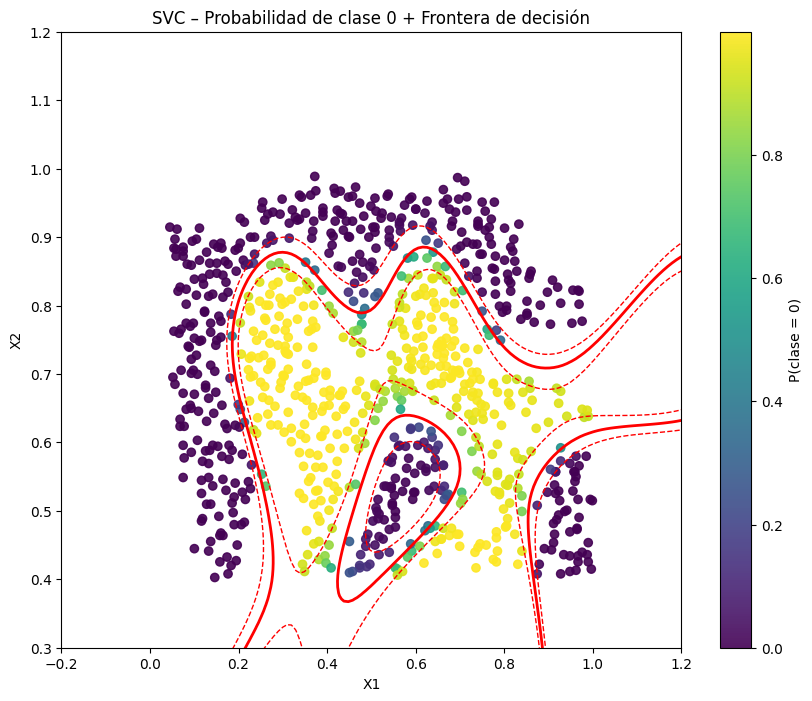

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Probabilidad de predecir clase 0
probs = svc.predict_proba(X2[['X1','X2']])[:, 0]

# Crear malla para la frontera de decisión
x_min, x_max = X2['X1'].min() - 1, X2['X1'].max() + 1
y_min, y_max = X2['X2'].min() - 1, X2['X2'].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Obtener decision_function en la malla
Z = svc.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(10,8))

# Scatter con probabilidad de clase 0
scatter = plt.scatter(
    X2['X1'], 
    X2['X2'], 
    c=probs, 
    cmap='viridis', 
    alpha=0.9
)

plt.colorbar(scatter, label='P(clase = 0)')

# Frontera de decisión y márgenes
plt.contour(
    xx, yy, Z,
    levels=[0],            # frontera
    colors='red',
    linewidths=2
)

plt.contour(
    xx, yy, Z,
    levels=[-1, 1],        # márgenes
    colors='red',
    linestyles='--',
    linewidths=1
)

plt.xlim(-0.2, 1.2)
plt.ylim(0.3, 1.2)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('SVC – Probabilidad de clase 0 + Frontera de decisión')
plt.show();
